In [31]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from pathlib import Path
from io import StringIO


In [22]:


def set_modern_style(dpi: int = 150) -> None:
    """Apply lightweight, publication-friendly rcParams."""
    mpl.rcParams.update({
        "figure.dpi": dpi,
        "savefig.dpi": 300,
        "font.family": "DejaVu Sans",
        "text.color":  "#2E2E2E",
        "axes.labelcolor": "#2E2E2E",
        "axes.edgecolor": "#D0D0D0",
        "axes.linewidth": 0.8,
        "axes.grid": False,          # leave off here; we’ll add custom grid below
        "legend.frameon": False,
        "legend.fontsize": 9,
    })
    sns.set_style("white")


def xbar_chart_seaborn(
    csv_path: str | Path,
    value_col: str = "Value",
    gt_col: str = "IsAnomaly_GT",
    subgroup_size: int = 1,
    k: float = 3.0,
    fig_size: tuple[int, int] = (18, 6),
    style_palette: dict | None = None,
    title: str | None = None,
    show: bool = True,
):
    """Draw a clean, modern X-bar chart with TP / FP / FN markers **and a light grid**."""
    # colour palette
    pal = dict(
        line_color="#34495E",
        tp_color  ="#E63946",
        fp_color  ="#F1C40F",
        fn_color  ="#95A5A6",
    )
    if style_palette:
        pal.update(style_palette)

    # ── load data ───────────────────────────────────────────────────
    df = pd.read_csv(csv_path)
    for c in (value_col, gt_col):
        if c not in df.columns:
            raise KeyError(f"Column {c!r} missing in {csv_path}")

    # ── subgroup stats ──────────────────────────────────────────────
    df["subgroup"] = np.repeat(
        np.arange(np.ceil(len(df) / subgroup_size).astype(int)),
        subgroup_size,
    )[: len(df)]

    grp      = df.groupby("subgroup")
    xbar     = grp[value_col].mean()
    gt_flags = (grp[gt_col].max() > 0).astype(int)

    mu    = xbar.mean()
    sigma = grp[value_col].std(ddof=1).mean() if subgroup_size > 1 else df[value_col].std(ddof=1)
    ucl, lcl = mu + k * sigma, mu - k * sigma
    alarms   = (xbar > ucl) | (xbar < lcl)

    tp =  alarms & (gt_flags == 1)
    fp =  alarms & (gt_flags == 0)
    fn = ~alarms & (gt_flags == 1)
    tn = ~alarms & (gt_flags == 0)

    # ── plot ────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=fig_size)

    # gentle grid (both axes)
    ax.grid(
        True, which="both",
        linestyle="--", linewidth=0.7, color="#DCDCDC", alpha=0.4
    )

    sns.lineplot(
        x=xbar.index, y=xbar.values,
        marker="o", linewidth=1.6,
        color=pal["line_color"], ax=ax,
    )

    for y, lbl in [(ucl, f"UCL (+{k}σ)"),
                   (mu,  "Center Line"),
                   (lcl, f"LCL (−{k}σ)")]:
        ax.axhline(
            y, linestyle="--", linewidth=1.1,
            color="crimson" if "CL" not in lbl else "#7F8C8D",
            label=lbl,
        )

    # ♦ TP | ⨯ FP | ○ FN
    ax.scatter(tp.index[tp], xbar[tp], marker="D", s=110,
               color=pal["tp_color"], label="TP")
    ax.scatter(fp.index[fp], xbar[fp], marker="X", s=130,
               color=pal["fp_color"], label="FP")
    ax.scatter(fn.index[fn], xbar[fn], marker="o", s=120,
               facecolors="none", edgecolors=pal["fn_color"],
               linewidths=1.6, label="FN")

    ax.set_xlabel("Subgroup Index", labelpad=10)
    ax.set_ylabel("Subgroup Mean",  labelpad=10)
    ax.set_title(title or f"X-bar Chart  (k = {k}, n = {subgroup_size})",
                 fontsize=16, pad=12)

    ax.legend(ncol=2, loc="upper right")
    sns.despine(trim=True)
    fig.tight_layout(pad=2)

    if show:
        plt.show()

    return {
        "ax": ax, "xbar": xbar,
        "ucl": ucl, "lcl": lcl, "grand_mean": mu, "sigma": sigma,
        "tp_mask": tp, "fp_mask": fp, "fn_mask": fn, "tn_mask": tn,
    }


# apply style on import
set_modern_style()


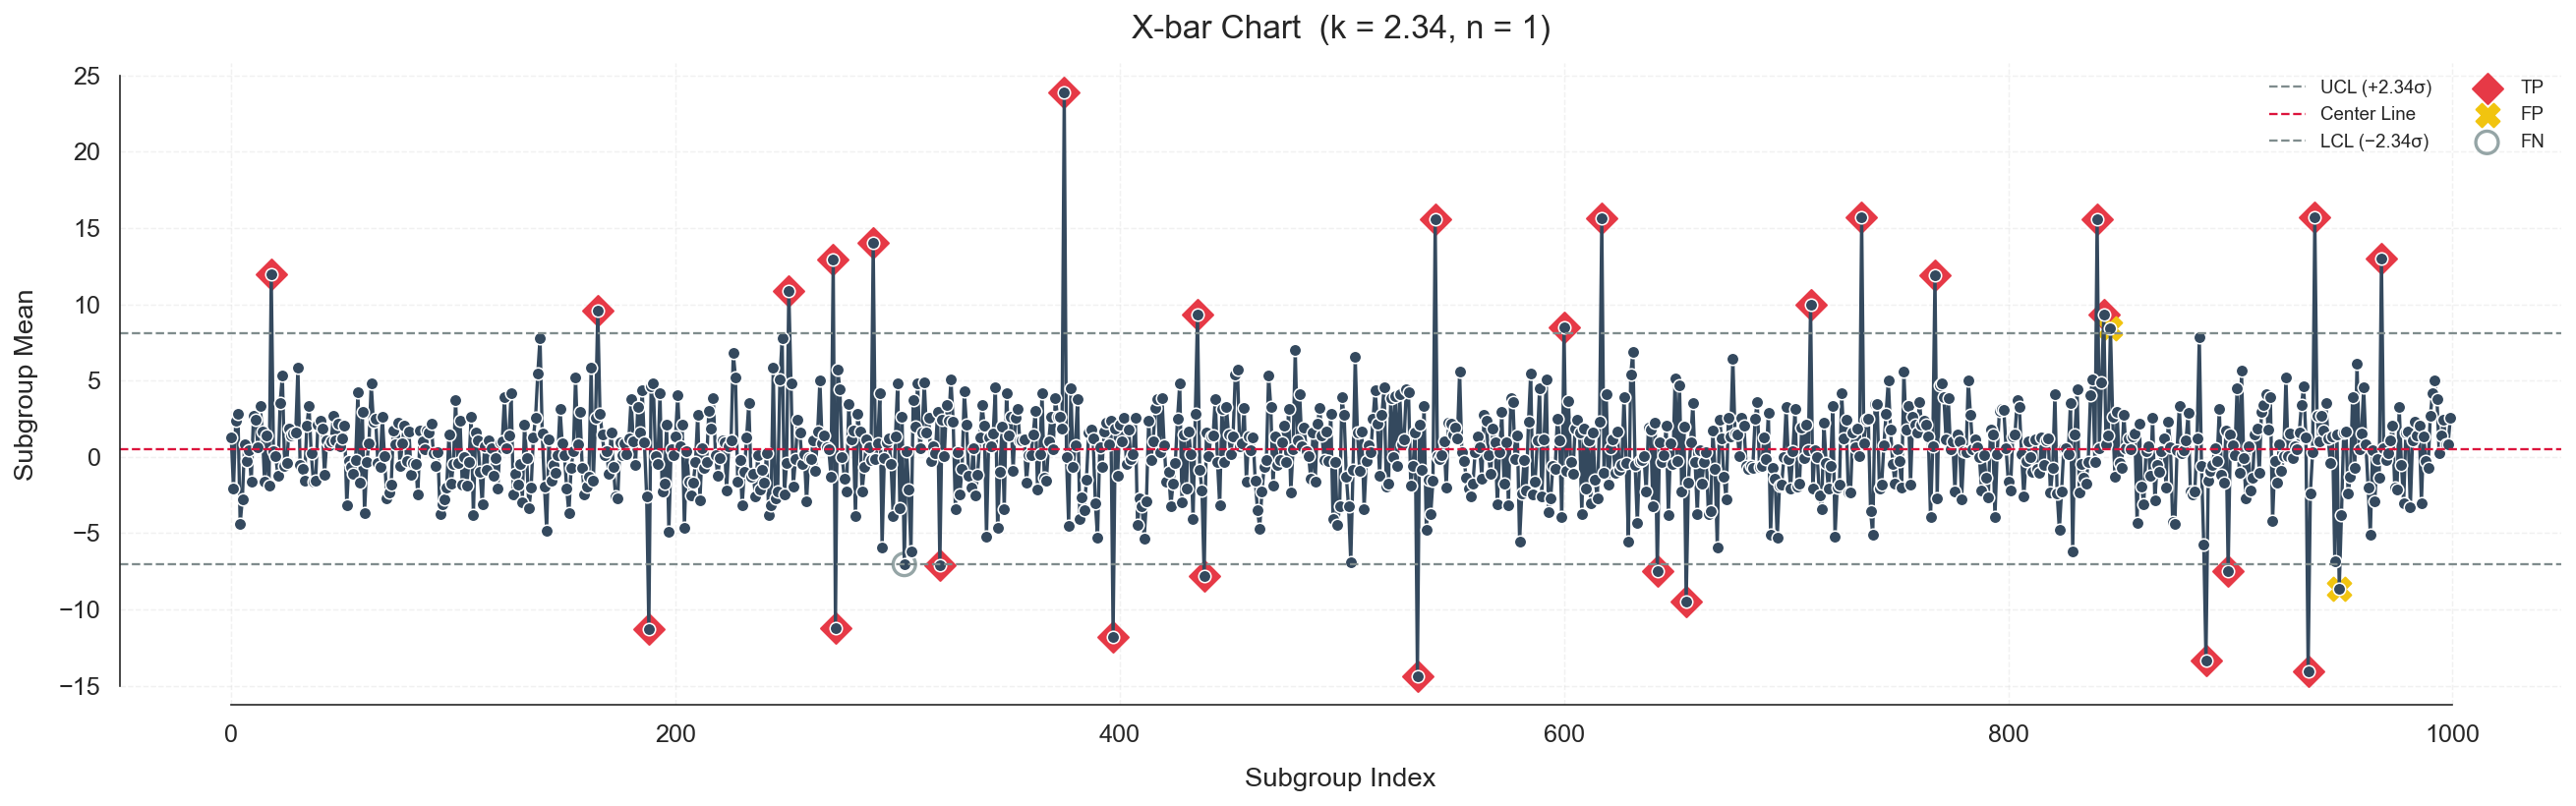

TP: 28  |  FP: 2  |  FN: 1


In [ ]:

results = xbar_chart_seaborn("spc_mixed.csv", subgroup_size=1, k=2.34)

print(f"TP: {results['tp_mask'].sum()}  |  "
      f"FP: {results['fp_mask'].sum()}  |  "
      f"FN: {results['fn_mask'].sum()}")


In [ ]:
from __future__ import annotations   

from pathlib import Path
from typing import IO, Union

import numpy as np
import pandas as pd


# --------------------------------------------------------------------------- #
# Main API                                                                    #
# --------------------------------------------------------------------------- #
def calculate_cost(
    data: Union[str, Path, IO, pd.DataFrame],
    *,
    k: float = 3.0,
    subgroup_size: int = 1,
    cost_fp: float = 1.0,
    cost_fn: float = 10.0,
    cost_ooc: float = 0.5,
    value_col: str = "Value",
    gt_col: str = "IsAnomaly_GT",
) -> pd.DataFrame:
    """
    Estimate the economic impact of a Shewhart **X-bar** chart with user-defined
    control-limit multiplier *k*.

    Parameters
    ----------
    data
        • A path/URL, file-like object, or an in-memory *pandas* ``DataFrame``.  
        • If a path/URL is supplied it is read with ``pd.read_csv``.
    k
        Control-limit multiplier (CL = μ ± k σ).
    subgroup_size
        Number of observations per subgroup (``1`` ⇒ individuals chart).
    cost_fp, cost_fn, cost_ooc
        Unit costs for *false positives*, *false negatives*, and every
        *out-of-control* alarm (FP + TP) respectively.
    value_col, gt_col
        Column names for the measurement and the ground-truth anomaly flag
        (0 = normal, 1 = anomaly).

    Returns
    -------
    pandas.DataFrame
        A tidy summary with counts, unit costs, and total costs.

    Notes
    -----
    * Assumes the ground-truth column already flags the *entire subgroup*
      when **any** point inside it is anomalous.
    * Uses unbiased ``ddof = 1`` estimates for σ.
    """
    # --------------------------------------------------------------------- #
    # 1) Load / validate input                                              #
    # --------------------------------------------------------------------- #
    if isinstance(data, pd.DataFrame):
        df = data.copy()
    else:
        df = pd.read_csv(data)        # Path / URL / buffer auto-detected

    missing = {value_col, gt_col} - set(df.columns)
    if missing:
        raise KeyError(f"Missing required column(s): {', '.join(missing)}")

    # --------------------------------------------------------------------- #
    # 2) Build subgroups                                                    #
    # --------------------------------------------------------------------- #
    n_rows = len(df)
    n_groups = int(np.ceil(n_rows / subgroup_size))

    df = df.assign(
        subgroup=np.repeat(np.arange(n_groups), subgroup_size)[:n_rows]
    )

    grp = df.groupby("subgroup", sort=False)
    xbar = grp[value_col].mean()
    gt_flags = grp[gt_col].max().astype(bool)   # True if *any* anomaly

    # --------------------------------------------------------------------- #
    # 3) Control limits                                                     #
    # --------------------------------------------------------------------- #
    grand_mean = xbar.mean()
    sigma_hat = (
        grp[value_col].std(ddof=1).mean()       # ☜ pooled within-subgroup σ̂
        if subgroup_size > 1
        else df[value_col].std(ddof=1)          # individuals chart
    )

    lcl, ucl = grand_mean - k * sigma_hat, grand_mean + k * sigma_hat
    alarms = (xbar < lcl) | (xbar > ucl)

    # --------------------------------------------------------------------- #
    # 4) Confusion matrix counts                                            #
    # --------------------------------------------------------------------- #
    fp = int((alarms & ~gt_flags).sum())
    fn = int((~alarms & gt_flags).sum())
    tp = int((alarms & gt_flags).sum())
    ooc = int(alarms.sum())   # TP + FP

    # --------------------------------------------------------------------- #
    # 5) Assemble tidy cost table                                           #
    # --------------------------------------------------------------------- #
    summary = pd.DataFrame(
        {
            "Metric": ["False Positive (FP)", "False Negative (FN)", "OOC Alarms"],
            "Count": [fp, fn, ooc],
            "Unit Cost": [cost_fp, cost_fn, cost_ooc],
        }
    )
    summary["Total Cost"] = summary["Count"] * summary["Unit Cost"]
    summary.loc[len(summary)] = {
        "Metric": "— TOTAL —",
        "Count": summary["Total Cost"].sum(),
        "Unit Cost": "",
        "Total Cost": "",
    }

    return summary.set_index("Metric", drop=True)


In [25]:
summary_df = calculate_cost(
    "spc_mixed.csv",  # path to your full dataset
    k= 2.34,              # ±3 σ limits
    cost_fp=1.0,      # unit cost for a false alarm
    cost_fn=10.0,     # unit cost for a missed anomaly
    cost_ooc=0.5      # cost per out-of-control alarm (TP + FP)
)

summary_df


,Count,Unit Cost,Total Cost
Metric,,,
False Positive (FP),2.0,1.0,2.0
False Negative (FN),1.0,10.0,10.0
OOC Alarms,30.0,0.5,15.0
— TOTAL —,27.0,,


In [26]:
from pathlib import Path
from typing   import Tuple

import numpy as np
import pandas as pd

def optimise_k(
    csv_path: str | Path,
    *,
    # ───── cost model ───────────────────────────────────────────
    cost_fn:  float,      # penalty per false-negative  (missed anomaly)
    cost_fp:  float,      # penalty per false-positive  (nuisance alarm)
    cost_ooc: float,      # handling cost *per alarm*  (labour, downtime…)
    # ───── k search range ──────────────────────────────────────
    k_min: float,
    k_max: float,
    step:  float = 0.05,
    # ───── constraints (all independently switchable)───────────
    # C-1  alarm-rate  ≤ max_alarm_rate
    max_alarm_rate: float | None = None,
    use_alarm_rate: bool = True,
    # C-2  total-cost   ≤ max_total_cost
    max_total_cost: float | None = None,
    use_total_cost: bool = True,
    # C-3  recall       ≥ min_recall            (recall = 1 - FN / anomalies)
    min_recall: float | None = None,
    use_min_recall: bool = False,
    # C-4  FP-rate      ≤ max_fp_rate           (FP-rate = FP / N)
    max_fp_rate: float | None = None,
    use_fp_rate: bool = False,
) -> Tuple[float, pd.DataFrame]:
    """
    Returns
    -------
    k_star : float
        The cost-minimising k that satisfies every *active* constraint.
    report : pd.DataFrame
        One row per k with columns:
        ['k','cost','alarms','fp','fn','alarm_rate','recall','fp_rate','feasible']
    """

    # ───────────────────────────────────────────────────────────
    # 1) Load and pre-compute stats
    # ───────────────────────────────────────────────────────────
    df      = pd.read_csv(csv_path)
    values  = df["Value"].to_numpy()
    gt      = df["IsAnomaly_GT"].to_numpy().astype(int)   # 1 = anomaly
    mu      = values.mean()
    sigma   = values.std(ddof=1)
    n       = values.size
    n_an    = gt.sum() or 1        # avoid /0 when dataset has no anomalies

    rows = []

    # ───────────────────────────────────────────────────────────
    # 2) Grid-search over k
    # ───────────────────────────────────────────────────────────
    for k in np.arange(k_min, k_max + step, step):
        lcl, ucl  = mu - k * sigma, mu + k * sigma
        ooc_mask  = (values < lcl) | (values > ucl)
        alarms    = int(ooc_mask.sum())

        fp = int(((ooc_mask) & (gt == 0)).sum())   # false positives
        fn = int((~ooc_mask & (gt == 1)).sum())    # false negatives

        alarm_rate = alarms / n
        recall     = 1.0 - fn / n_an
        fp_rate    = fp / n

        cost = (fp * cost_fp) + (fn * cost_fn) + (alarms * cost_ooc)

        # ── check each active constraint ───────────────────────
        ok_alarm_rate = (not use_alarm_rate) or (
            max_alarm_rate is None or alarm_rate <= max_alarm_rate
        )
        ok_total_cost = (not use_total_cost) or (
            max_total_cost is None or cost <= max_total_cost
        )
        ok_recall = (not use_min_recall) or (
            min_recall is None or recall >= min_recall
        )
        ok_fp_rate = (not use_fp_rate) or (
            max_fp_rate is None or fp_rate <= max_fp_rate
        )

        feasible = ok_alarm_rate and ok_total_cost and ok_recall and ok_fp_rate

        rows.append(dict(
            k=k, cost=cost, alarms=alarms, fp=fp, fn=fn,
            alarm_rate=alarm_rate, recall=recall, fp_rate=fp_rate,
            feasible=feasible
        ))

    report = pd.DataFrame(rows)

    # ───────────────────────────────────────────────────────────
    # 3) Pick best feasible k
    # ───────────────────────────────────────────────────────────
    feasible_rows = report[report.feasible]
    if feasible_rows.empty:
        raise ValueError(
            "No k satisfies the active constraints. "
            "Relax limits or disable constraints."
        )

    k_star = feasible_rows.loc[feasible_rows.cost.idxmin(), "k"]
    return float(k_star), report.reset_index(drop=True)

In [27]:
best_k, results = optimise_k(
    csv_path       = "spc_mixed.csv",
        cost_fn        = 10.0,
        cost_fp        = 1.0,
        cost_ooc       = 0.5,
        k_min          = 1.0,
        k_max          = 5.0,
        step           = 0.01,
        # C-1: ≤ 2 % alarms / 100 points
        max_alarm_rate = 0.03, use_alarm_rate=True,
        # C-2: budget ceiling
        max_total_cost = 1_000, use_total_cost=False,
        # C-3: must catch ≥ 95 % of real anomalies
        min_recall     = 0.95,  use_min_recall=True,
        # C-4: ≤ 1 % false positives
        max_fp_rate    = 0.01,  use_fp_rate=True,
    )

print(f"Optimal k = {best_k:.2f}")
results   



Optimal k = 2.34


,k,cost,alarms,fp,fn,alarm_rate,recall,fp_rate,feasible
0,1.00,302.5,221,192,0,0.221,1.000000,0.192,False
1,1.01,292.0,214,185,0,0.214,1.000000,0.185,False
2,1.02,289.0,212,183,0,0.212,1.000000,0.183,False
3,1.03,278.5,205,176,0,0.205,1.000000,0.176,False
4,1.04,277.0,204,175,0,0.204,1.000000,0.175,False
...,...,...,...,...,...,...,...,...,...
396,4.96,280.5,1,0,28,0.001,0.034483,0.000,False
397,4.97,280.5,1,0,28,0.001,0.034483,0.000,False
398,4.98,280.5,1,0,28,0.001,0.034483,0.000,False
399,4.99,280.5,1,0,28,0.001,0.034483,0.000,False


In [28]:
import matplotlib.pyplot as plt
from typing import List
import pandas as pd

import seaborn as sns

def plot_k_separate_modern(
    df: pd.DataFrame,
    metrics: List[str],
    xlabel: str = 'k',
    ylabel: str = 'Value'
):
    """
    Plot each metric against k in its own modern-styled figure using seaborn.

    Parameters
    ----------
    df : pd.DataFrame
        Must contain a 'k' column and the specified metrics.
    metrics : List[str]
        List of column names in df to plot on the y-axis.
    xlabel : str
        Label for the x-axis (default: 'k').
    ylabel : str
        Label for the y-axis (default: 'Value').
    """
    sns.set(style="whitegrid", palette="muted", font_scale=1.1)
    
    for metric in metrics:
        if metric not in df.columns:
            raise ValueError(f"Column '{metric}' not found in DataFrame.")
        plt.figure(figsize=(8, 5))
        sns.lineplot(data=df, x='k', y=metric, marker="o")
        plt.title(f'{metric} vs k', fontsize=14, weight='bold')
        plt.xlabel(xlabel)
        plt.ylabel(metric if ylabel == 'Value' else ylabel)
        plt.tight_layout()
        plt.show()



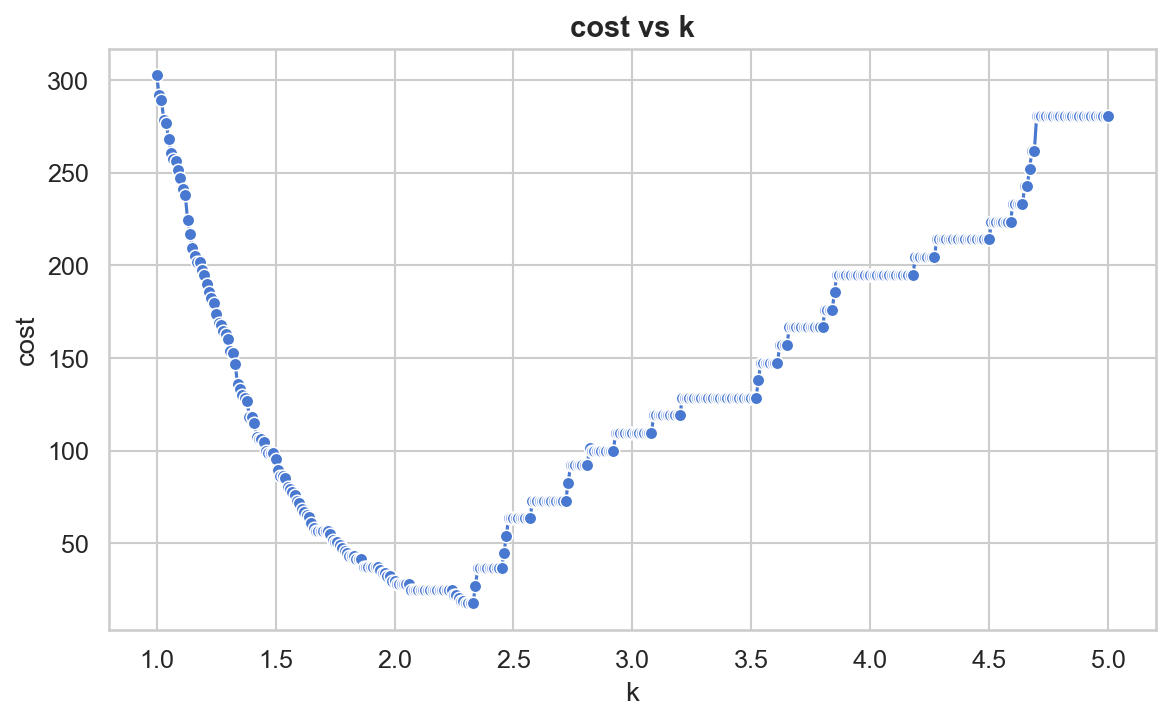

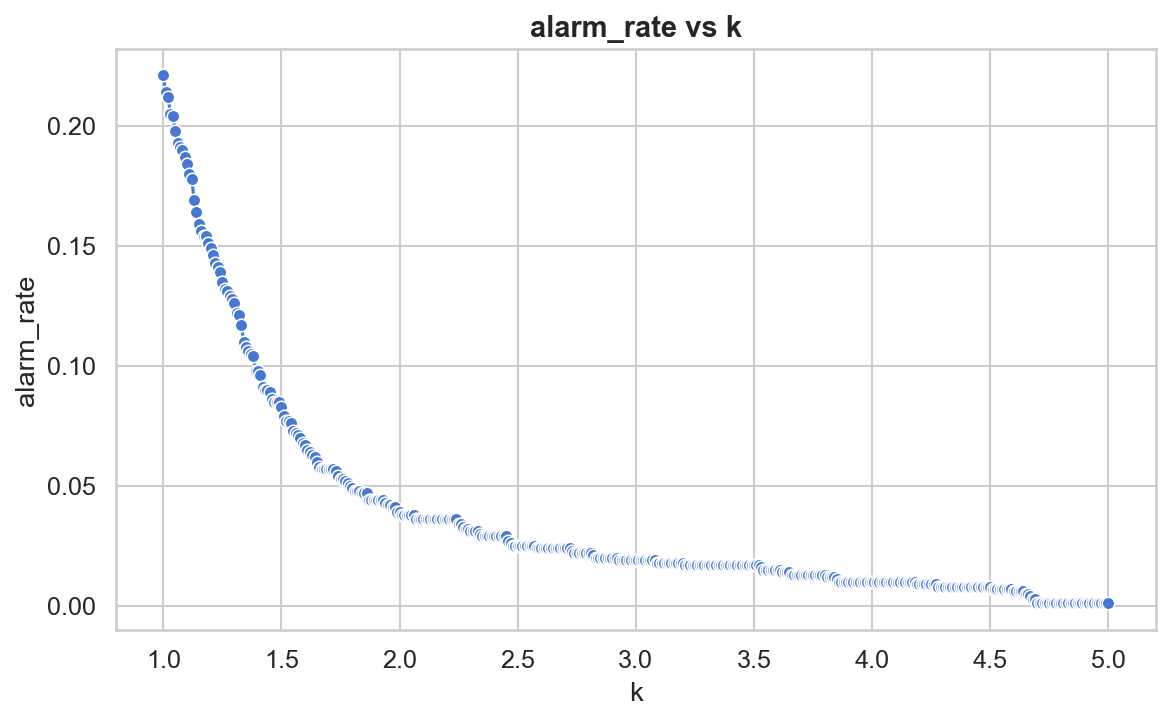

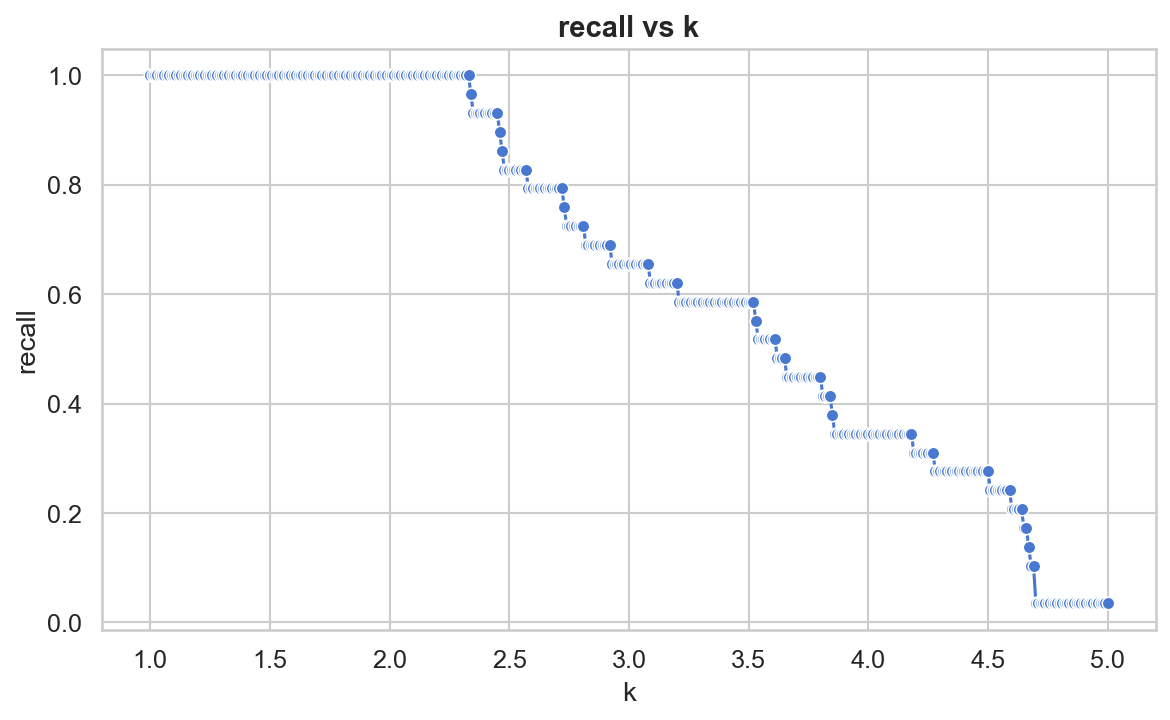

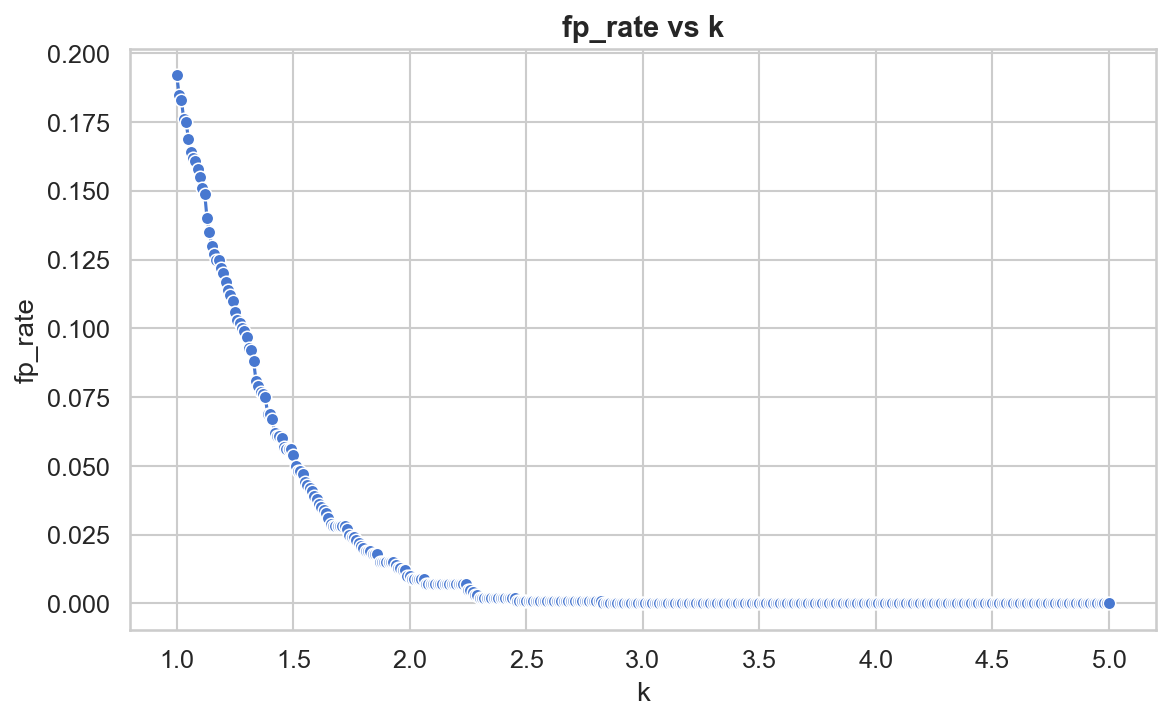

In [29]:
plot_k_separate_modern(results  , ['cost', 'alarm_rate', 'recall','fp_rate'])